We should make this a **formal validation gate** before we allow the textbook corpus to move toward chunking and FAISS.

I also reproduced the comparison on the actual Das & Sobhan PDF here before setting up the procedure. The pattern is exactly what we suspected: PyMuPDF, `pypdf`, `pdfplumber`, and Poppler all encounter the mathematical encoding problem, but they expose it differently. So now we want to document that properly rather than relying on an informal observation.

The baseline paper only says that PDF/DOCX/TXT documents were loaded with “appropriate loaders”; it does **not** identify the specific PDF parser. It then specifies `CharacterTextSplitter` with `chunk_size=200`, `chunk_overlap=10`, OpenAI embeddings, and FAISS.  Therefore, this parser choice is legitimately a **reconstructed baseline decision**, and testing alternatives is the right thing to do.

## Parser audit plan

We will compare four normal PDF-reading approaches:

| Candidate                       | Why include it                                                                |
| ------------------------------- | ----------------------------------------------------------------------------- |
| **PyMuPDF**                     | Our current candidate and gives us coordinates/glyph information              |
| **pypdf**                       | Underlies LangChain's common `PyPDFLoader`; plausible baseline implementation |
| **pdfplumber**                  | Strong layout/character-level extraction comparator                           |
| **Poppler `pdftotext -layout`** | Independent mature PDF engine; useful cross-check                             |

We will **not** include Mathpix, OCR, equation-to-LaTeX systems, vision models, symbolic reconstruction, etc. Those would already be formula-aware enhancements rather than a normal baseline PDF loader.

And we will not use any of the Hard-20 problem pages to choose the winner.

### What we will score

For each parser, on the same fixed pages:

1. **Text completeness** – was the printed textual information retained?
2. **Reading order** – did sentences/equations remain near the right surrounding text?
3. **Mathematical glyph preservation** – how much of the printed equation survives?
4. **Equation structure/layout** – numerator/denominator, superscripts, subscripts, equation components.
5. **General layout robustness** – tables, mixed text/formula areas, etc.
6. **Auditability** – whether we can inspect why something failed.

The first five will be based on the visible PDF page as ground truth. Number 6 is a technical implementation criterion.

We should **not automatically give PyMuPDF extra points because it is already our choice**.

# Step 1 - create the audit notebook and record the environment

### Why we're doing this first

We **don't install anything yet**.

There are two reasons.

First, if `pypdf`, `pdfplumber`, or `Poppler` are already installed because of other dependencies, we need to know the versions that existed before this experiment.

Second, adding packages is itself a change to the reproducible thesis environment. If something is missing, we'll install it deliberately and then update the appropriate dependency/version records rather than casually running `pip install` and forgetting about it.

Our parser decision will then have a documented chain:

```text
Baseline paper does not report PDF loader
             ↓
Candidate loaders identified
             ↓
Versions recorded
             ↓
Fixed representative pages selected
             ↓
Same pages extracted by all four parsers
             ↓
Visual source PDF treated as ground truth
             ↓
Extraction results scored
             ↓
Parser selected and justified
             ↓
Choice frozen before chunking/FAISS
```

That fits particularly well with the CDS dissertation requirements: the handbook expects the Approach chapter to explain preprocessing, design choices, assumptions, technical implementation and reproducibility. 

In [1]:
# Import importlib.metadata so installed Python package versions can be recorded reproducibly.
from importlib import metadata

# Import shutil so we can check whether the Poppler command-line executable is available.
import shutil

# Import subprocess so the installed Poppler version can be queried without modifying the environment.
import subprocess

# Import sys so the Python interpreter version and executable path can be recorded.
import sys


# Print the Python version used by the active thesis notebook kernel.
print("Python version:")
print(sys.version)

# Print the exact Python executable to confirm that the notebook is using the thesis virtual environment.
print("\nPython executable:")
print(sys.executable)


# Define the Python packages that will be considered in the PDF parser comparison.
packages = [
    "PyMuPDF",
    "pypdf",
    "pdfplumber",
]

# Print a heading for the installed Python parser versions.
print("\nPython PDF parser packages:")

# Loop through every required Python package.
for package_name in packages:
    # Attempt to retrieve the installed package version without importing the package itself.
    try:
        # Read and print the installed package version.
        package_version = metadata.version(package_name)

        # Report the package as available together with its exact version.
        print(f"{package_name}: {package_version}")

    # Handle the case where the package is not currently installed.
    except metadata.PackageNotFoundError:
        # Record the package as missing rather than installing it automatically.
        print(f"{package_name}: NOT INSTALLED")


# Locate the Poppler pdftotext executable on the current operating system.
pdftotext_path = shutil.which("pdftotext")

# Print a heading for the Poppler availability check.
print("\nPoppler / pdftotext:")

# Check whether the executable was found.
if pdftotext_path is not None:
    # Print the exact executable path so its source is reproducible.
    print(f"Executable: {pdftotext_path}")

    # Run pdftotext with the version option and capture its output without modifying any files.
    poppler_result = subprocess.run(
        [pdftotext_path, "-v"],
        capture_output=True,
        text=True,
        check=False,
    )

    # Combine standard output and standard error because Poppler commonly prints its version to stderr.
    poppler_version_output = (
        poppler_result.stdout + poppler_result.stderr
    ).strip()

    # Print the complete Poppler version information returned by the executable.
    print(poppler_version_output)

# Handle the case where Poppler is not installed or not available on PATH.
else:
    # Report the missing executable without making any installation changes.
    print("pdftotext: NOT FOUND")

Python version:
3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]

Python executable:
/home/zaki/coding_F/GismaProjects/Thesis/.venv/bin/python

Python PDF parser packages:
PyMuPDF: 1.28.2
pypdf: 6.16.2
pdfplumber: 0.11.10

Poppler / pdftotext:
Executable: /usr/bin/pdftotext
pdftotext version 24.02.0
Copyright 2005-2024 The Poppler Developers - http://poppler.freedesktop.org
Copyright 1996-2011, 2022 Glyph & Cog, LLC


# Step 2: freeze the audit pages

## Fixed parser-audit sample

The PDF parser is not specified by Tophel et al. (2025), so the parser used for the reconstructed baseline must be selected through an explicit extraction-quality audit.

The audit pages were fixed before comparing parser outputs. They were selected to cover different document structures while avoiding the Hard-20 evaluation questions used by the baseline study.

The audit evaluates ordinary PDF text extraction only. No OCR, mathematical reconstruction, LaTeX conversion, formula correction, or semantic cleaning is applied.

Selected cases:

- Case A: printed page 2, PDF page 26, prose + table + figure.
- Case B: printed page 171, PDF page 195, equations 6.19-6.23 and mathematical notation.
- Case C: printed page 199, PDF page 223, Bernoulli equations and mixed equation/figure layout.
- Case D: printed page 399, PDF page 423, multi-line numerical equations, units, superscripts, and subscripts.
- Case E: printed page 429, PDF page 453, Mohr-Coulomb equations and specialised mathematical symbols.

The visible rendered PDF page is treated as the reference representation when assessing extraction fidelity.

## Step 2.1: encode and validate the fixed sample

In [2]:
# Import Path so project and textbook paths can be handled independently of the operating system.
from pathlib import Path

# Import PyMuPDF using its current supported module name.
import pymupdf


# Resolve the repository root from the notebook location.
# When the notebook runs from the notebooks directory, move one directory upward.
current_directory = Path.cwd().resolve()

# Check whether the notebook working directory is the notebooks folder.
if current_directory.name == "notebooks":
    # Use the parent directory as the repository root.
    project_root = current_directory.parent

# Otherwise assume the current directory is already the repository root.
else:
    # Keep the current directory as the project root.
    project_root = current_directory


# Define the exact location of the renamed Das and Sobhan textbook inside the raw corpus directory.
pdf_path = (
    project_root
    / "data"
    / "raw"
    / "corpus"
    / "das-sobhan-principles-geotechnical-engineering-8e-si.pdf"
)

# Stop immediately if the expected textbook file does not exist.
assert pdf_path.exists(), f"Textbook PDF not found: {pdf_path}"


# Define the parser-audit sample before any parser outputs are compared.
# pdf_page is the human-visible PDF page number.
# page_index is the zero-based page index required by Python PDF libraries.
audit_pages = [
    {
        "case_id": "A",
        "printed_page": 2,
        "pdf_page": 26,
        "page_index": 25,
        "structure": "prose + table + figure",
        "reference_marker": "Table 1.1",
    },
    {
        "case_id": "B",
        "printed_page": 171,
        "pdf_page": 195,
        "page_index": 194,
        "structure": "equations + ratios + subscripts + percentages",
        "reference_marker": "6.10 Specifications for Field Compaction",
    },
    {
        "case_id": "C",
        "printed_page": 199,
        "pdf_page": 223,
        "page_index": 222,
        "structure": "equations + fractions + variables + figure",
        "reference_marker": "7.2 Bernoulli",
    },
    {
        "case_id": "D",
        "printed_page": 399,
        "pdf_page": 423,
        "page_index": 422,
        "structure": "multi-line calculation + superscripts + subscripts + units",
        "reference_marker": "Example 11.10",
    },
    {
        "case_id": "E",
        "printed_page": 429,
        "pdf_page": 453,
        "page_index": 452,
        "structure": "Mohr-Coulomb equations + specialised mathematical symbols",
        "reference_marker": "12.2 Mohr",
    },
]


# Open the textbook only for structural validation of the selected page numbers.
document = pymupdf.open(pdf_path)

# Print the resolved source path for reproducibility.
print(f"Textbook: {pdf_path}")

# Print the number of pages detected in this exact textbook file.
print(f"Total PDF pages: {document.page_count}")

# Verify that the expected electronic textbook contains 770 PDF pages.
assert document.page_count == 770, (
    f"Unexpected textbook length: {document.page_count} pages instead of 770."
)

# Print the frozen audit sample and verify each mapping.
print("\nFrozen parser-audit sample:")

# Iterate over each pre-selected audit case.
for audit_case in audit_pages:
    # Verify that the human PDF page number and zero-based index agree.
    assert audit_case["page_index"] == audit_case["pdf_page"] - 1

    # Load the selected page using its zero-based page index.
    page = document.load_page(audit_case["page_index"])

    # Extract plain text only for a coarse page-identity check, not for parser scoring.
    validation_text = page.get_text("text")

    # Test whether the expected identifying phrase appears on the selected page.
    marker_found = audit_case["reference_marker"].lower() in validation_text.lower()

    # Print the complete audit-page identity information.
    print(
        f"Case {audit_case['case_id']}: "
        f"printed={audit_case['printed_page']}, "
        f"pdf={audit_case['pdf_page']}, "
        f"index={audit_case['page_index']}, "
        f"marker_found={marker_found}, "
        f"structure={audit_case['structure']}"
    )

# Close the textbook after page validation is complete.
document.close()

Textbook: /home/zaki/coding_F/GismaProjects/Thesis/data/raw/corpus/das-sobhan-principles-geotechnical-engineering-8e-si.pdf
Total PDF pages: 770

Frozen parser-audit sample:
Case A: printed=2, pdf=26, index=25, marker_found=True, structure=prose + table + figure
Case B: printed=171, pdf=195, index=194, marker_found=True, structure=equations + ratios + subscripts + percentages
Case C: printed=199, pdf=223, index=222, marker_found=True, structure=equations + fractions + variables + figure
Case D: printed=399, pdf=423, index=422, marker_found=True, structure=multi-line calculation + superscripts + subscripts + units
Case E: printed=429, pdf=453, index=452, marker_found=True, structure=Mohr-Coulomb equations + specialised mathematical symbols


Perfect. All five cases validated exactly as intended, so **the audit sample is now frozen**.

That matters because from this point onward we should not replace pages because one parser happens to perform badly on them. The sample was selected independently of parser results and independently of the Hard-20 benchmark.

So our experimental state is now:

```text
5 fixed source pages
        ↓
same exact PDF
        ↓
4 ordinary PDF extraction approaches
        ↓
no OCR
no formula correction
no semantic cleaning
no manual reconstruction
        ↓
compare extraction fidelity
```

This is also useful for the dissertation because GISMA expects us to explain preprocessing choices, assumptions, reproducibility and technical implementation decisions rather than simply naming tools. 

# Step 3: implement the four raw extractors

Before scoring anything, we first want to capture what each parser actually returns.

For this first comparison I want to use the **normal text extraction interface of each library**, without trying to optimise one parser differently from the others.

That gives us:

* PyMuPDF: `page.get_text("text")`
* pypdf: `page.extract_text()`
* pdfplumber: `page.extract_text()`
* Poppler: `pdftotext`

No reconstruction and no replacement of strange characters.

For Poppler, we will use `-layout`, because `pdftotext` explicitly provides that as its ordinary layout-preserving text mode. We will record that choice. We will later see whether this gives Poppler an advantage in page structure, but it does not interpret equations semantically.

In [3]:
# Import PyMuPDF using its current supported module name.
import pymupdf

# Import PdfReader so pages can be extracted using pypdf.
from pypdf import PdfReader

# Import pdfplumber so the same pages can be extracted through its PDFMiner-based text layer.
import pdfplumber

# Import shutil so the Poppler pdftotext executable can be located reproducibly.
import shutil

# Import subprocess so Poppler can be executed from the notebook.
import subprocess


# Define a function that extracts one page using ordinary PyMuPDF text extraction.
def extract_with_pymupdf(pdf_file, page_index):
    # Open the source PDF using PyMuPDF.
    document = pymupdf.open(pdf_file)

    # Load the requested zero-based page.
    page = document.load_page(page_index)

    # Extract the page using PyMuPDF's standard text extraction mode.
    text = page.get_text("text")

    # Close the document after extraction is complete.
    document.close()

    # Return the raw extracted text without semantic cleaning or mathematical correction.
    return text


# Define a function that extracts one page using ordinary pypdf text extraction.
def extract_with_pypdf(pdf_file, page_index):
    # Open the source PDF through pypdf.
    reader = PdfReader(str(pdf_file))

    # Select the requested zero-based page.
    page = reader.pages[page_index]

    # Extract text using pypdf's normal extraction method.
    text = page.extract_text()

    # Convert a possible None result into an empty string while leaving extracted content unchanged.
    if text is None:
        # Replace only the absence of output with an empty string.
        text = ""

    # Return the raw extracted text without semantic cleaning or mathematical correction.
    return text


# Define a function that extracts one page using ordinary pdfplumber text extraction.
def extract_with_pdfplumber(pdf_file, page_index):
    # Open the source PDF through pdfplumber.
    with pdfplumber.open(str(pdf_file)) as document:
        # Select the requested zero-based page.
        page = document.pages[page_index]

        # Extract text using pdfplumber's normal text extraction method.
        text = page.extract_text()

    # Convert a possible None result into an empty string while leaving extracted content unchanged.
    if text is None:
        # Replace only the absence of output with an empty string.
        text = ""

    # Return the raw extracted text without semantic cleaning or mathematical correction.
    return text


# Define a function that extracts one PDF page using Poppler's pdftotext executable.
def extract_with_poppler(pdf_file, pdf_page):
    # Locate the pdftotext executable available on the current operating system.
    pdftotext_executable = shutil.which("pdftotext")

    # Stop clearly if Poppler cannot be found.
    assert pdftotext_executable is not None, "Poppler pdftotext was not found."

    # Build the Poppler command for exactly one human-visible PDF page.
    command = [
        pdftotext_executable,
        "-f",
        str(pdf_page),
        "-l",
        str(pdf_page),
        "-layout",
        "-enc",
        "UTF-8",
        str(pdf_file),
        "-",
    ]

    # Execute Poppler and capture its text output directly in memory.
    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
        check=True,
    )

    # Return Poppler's raw standard output without semantic cleaning or mathematical correction.
    return result.stdout

### Why four separate functions?

I don't want to hide the differences behind one complicated abstraction yet.

For the audit it is actually better to be able to see explicitly:

```text
PyMuPDF        -> its own normal API
pypdf          -> its own normal API
pdfplumber     -> its own normal API
Poppler        -> its own normal command
```

Later, once we choose a production parser, **only that parser** gets integrated properly into the ingestion pipeline.

## Step 3.1: extract every frozen page with every parser

In [4]:
# Define the four parser names used throughout the audit.
parser_names = [
    "pymupdf",
    "pypdf",
    "pdfplumber",
    "poppler",
]


# Create a dictionary that will keep all raw parser outputs in notebook memory.
audit_outputs = {}


# Iterate through each previously frozen audit page.
for audit_case in audit_pages:
    # Read the unique identifier for the current audit case.
    case_id = audit_case["case_id"]

    # Create a nested dictionary for the current page.
    audit_outputs[case_id] = {}

    # Extract the current page with PyMuPDF.
    audit_outputs[case_id]["pymupdf"] = extract_with_pymupdf(
        pdf_path,
        audit_case["page_index"],
    )

    # Extract the same current page with pypdf.
    audit_outputs[case_id]["pypdf"] = extract_with_pypdf(
        pdf_path,
        audit_case["page_index"],
    )

    # Extract the same current page with pdfplumber.
    audit_outputs[case_id]["pdfplumber"] = extract_with_pdfplumber(
        pdf_path,
        audit_case["page_index"],
    )

    # Extract the same current page with Poppler.
    audit_outputs[case_id]["poppler"] = extract_with_poppler(
        pdf_path,
        audit_case["pdf_page"],
    )


# Print a compact confirmation rather than dumping the full copyrighted textbook text.
print("Raw extraction completed for all frozen audit cases.\n")

# Iterate through every frozen audit case.
for audit_case in audit_pages:
    # Read the current audit case identifier.
    case_id = audit_case["case_id"]

    # Print a heading for the current case.
    print(
        f"Case {case_id} "
        f"(printed page {audit_case['printed_page']}, "
        f"PDF page {audit_case['pdf_page']}):"
    )

    # Iterate through every parser.
    for parser_name in parser_names:
        # Retrieve the parser's raw output for this case.
        extracted_text = audit_outputs[case_id][parser_name]

        # Count the total number of characters returned by this parser.
        character_count = len(extracted_text)

        # Count the number of text lines returned by this parser.
        line_count = len(extracted_text.splitlines())

        # Print only structural statistics at this stage.
        print(
            f"  {parser_name:<11} "
            f"characters={character_count:<6} "
            f"lines={line_count}"
        )

    # Print a blank line between cases for readability.
    print()

Raw extraction completed for all frozen audit cases.

Case A (printed page 2, PDF page 26):
  pymupdf     characters=1371   lines=42
  pypdf       characters=1372   lines=23
  pdfplumber  characters=1366   lines=26
  poppler     characters=2281   lines=40

Case B (printed page 171, PDF page 195):
  pymupdf     characters=2200   lines=51
  pypdf       characters=2270   lines=49
  pdfplumber  characters=2305   lines=52
  poppler     characters=3073   lines=51

Case C (printed page 199, PDF page 223):
  pymupdf     characters=1390   lines=50
  pypdf       characters=1475   lines=48
  pdfplumber  characters=1472   lines=55
  poppler     characters=2602   lines=61

Case D (printed page 399, PDF page 423):
  pymupdf     characters=902    lines=52
  pypdf       characters=1137   lines=40
  pdfplumber  characters=1137   lines=45
  poppler     characters=1984   lines=52

Case E (printed page 429, PDF page 453):
  pymupdf     characters=1520   lines=28
  pypdf       characters=1534   lines=27
  

## What this step tells us

Not accuracy yet.

It tells us whether any parser is doing something obviously wrong such as:

```text
Case C
PyMuPDF      2,500 chars
pypdf        2,430 chars
pdfplumber   2,480 chars
Poppler      2,460 chars
```

which is normal,

versus something like:

```text
pdfplumber   17 chars
```

which would immediately indicate a serious extraction failure.

But **more characters does not mean better extraction**.

A parser could return:

```text
(cid:4)(cid:4)(cid:2)(cid:7)...
```

and technically have a high character count while conveying less useful information.

So this is only a structural sanity check.

## Step 3.2: automatically measure obvious extraction anomalies

Now we add a diagnostic layer that does **not correct anything**.

We specifically want to count things such as:

* Unicode control characters;
* Unicode replacement characters `�`;
* pdfplumber/PDFMiner `(cid:...)` placeholders;
* pypdf `/Hxxxxx`-style remnants;
* form-feed characters produced by command-line extraction.

In [5]:
# Import re so known parser placeholder patterns can be counted.
import re

# Import unicodedata so Unicode control characters can be identified objectively.
import unicodedata


# Define a function that counts suspicious extraction artefacts without modifying the text.
def count_extraction_anomalies(text):
    # Count Unicode replacement characters that indicate undecodable content.
    replacement_character_count = text.count("\ufffd")

    # Count PDFMiner-style CID placeholders such as "(cid:2)".
    cid_placeholder_count = len(
        re.findall(r"\(cid:\d+\)", text)
    )

    # Count pypdf-style /H numeric placeholders if they appear in extracted output.
    h_placeholder_count = len(
        re.findall(r"/H\d+", text)
    )

    # Count form-feed page-control characters.
    form_feed_count = text.count("\f")

    # Create a counter for Unicode control characters other than normal whitespace controls.
    unusual_control_count = 0

    # Inspect every extracted character individually.
    for character in text:
        # Read the Unicode category assigned to the current character.
        unicode_category = unicodedata.category(character)

        # Check whether the character belongs to the Unicode control-character category.
        if unicode_category == "Cc":
            # Ignore newline, carriage return, tab, and form feed because they are structural text controls.
            if character not in {"\n", "\r", "\t", "\f"}:
                # Count only unusual control characters that could represent broken mathematical encodings.
                unusual_control_count += 1

    # Return every anomaly count in a structured dictionary.
    return {
        "replacement_chars": replacement_character_count,
        "cid_placeholders": cid_placeholder_count,
        "h_placeholders": h_placeholder_count,
        "form_feeds": form_feed_count,
        "unusual_controls": unusual_control_count,
    }


# Create a dictionary that will store anomaly measurements for all parser outputs.
audit_anomalies = {}


# Iterate through every frozen audit case.
for audit_case in audit_pages:
    # Read the current case identifier.
    case_id = audit_case["case_id"]

    # Create storage for all parser diagnostics on this page.
    audit_anomalies[case_id] = {}

    # Iterate through every parser.
    for parser_name in parser_names:
        # Retrieve the parser's untouched raw output.
        extracted_text = audit_outputs[case_id][parser_name]

        # Measure obvious extraction anomalies without changing the source text.
        audit_anomalies[case_id][parser_name] = count_extraction_anomalies(
            extracted_text
        )


# Print the automatic anomaly report.
print("Automatic extraction-anomaly report:\n")

# Iterate through every audit case.
for audit_case in audit_pages:
    # Read the current case identifier.
    case_id = audit_case["case_id"]

    # Print a heading for the current audit page.
    print(f"Case {case_id}:")

    # Iterate through all four parsers.
    for parser_name in parser_names:
        # Retrieve the anomaly counts for this parser and page.
        anomalies = audit_anomalies[case_id][parser_name]

        # Print the measured anomaly counts.
        print(
            f"  {parser_name:<11} "
            f"replacement={anomalies['replacement_chars']:<3} "
            f"cid={anomalies['cid_placeholders']:<3} "
            f"/H={anomalies['h_placeholders']:<3} "
            f"controls={anomalies['unusual_controls']:<3} "
            f"formfeed={anomalies['form_feeds']}"
        )

    # Print a blank line between cases for readability.
    print()

Automatic extraction-anomaly report:

Case A:
  pymupdf     replacement=0   cid=0   /H=0   controls=0   formfeed=0
  pypdf       replacement=0   cid=0   /H=0   controls=0   formfeed=0
  pdfplumber  replacement=0   cid=0   /H=0   controls=0   formfeed=0
  poppler     replacement=0   cid=0   /H=0   controls=0   formfeed=1

Case B:
  pymupdf     replacement=0   cid=0   /H=0   controls=13  formfeed=0
  pypdf       replacement=0   cid=0   /H=13  controls=0   formfeed=0
  pdfplumber  replacement=0   cid=13  /H=0   controls=0   formfeed=0
  poppler     replacement=0   cid=0   /H=0   controls=0   formfeed=1

Case C:
  pymupdf     replacement=0   cid=0   /H=0   controls=16  formfeed=0
  pypdf       replacement=0   cid=0   /H=16  controls=0   formfeed=0
  pdfplumber  replacement=0   cid=16  /H=0   controls=0   formfeed=0
  poppler     replacement=0   cid=0   /H=0   controls=16  formfeed=1

Case D:
  pymupdf     replacement=0   cid=0   /H=0   controls=46  formfeed=0
  pypdf       replacement=0   


### Important: don't interpret the winner from this output alone

For example:

```text
PyMuPDF: controls=12
pdfplumber: cid=12
pypdf: /H=12
```

could actually mean **all three parsers failed on the exact same 12 mathematical glyphs**, simply representing the failure differently.

That's precisely the question we're trying to answer.

The real comparison therefore comes next, when we inspect the **same targeted mathematical regions visually against the actual rendered textbook pages**.

And that part is important because the Das & Sobhan PDF demonstrably contains mathematical notation that generic text extraction does not always represent faithfully. 

We'll then build a **controlled side-by-side viewer for selected regions** so we can score the four parsers based on what the PDF visibly contains rather than on arbitrary character counts.


## Results:

This is a very useful result already. We have not chosen a winner yet, but the pattern is strong enough to tell us something important about the source PDF.

For the ordinary prose/table page, Case A, **all four parsers produced zero mathematical/encoding anomalies**. So none of the parsers has a general problem reading this textbook.

For the mathematical pages, look at the counts:

| Case |     PyMuPDF |   pypdf | pdfplumber |        Poppler |
| ---- | ----------: | ------: | ---------: | -------------: |
| B    | 13 controls | 13 `/H` | 13 `(cid)` | **0 controls** |
| C    | 16 controls | 16 `/H` | 16 `(cid)` |    16 controls |
| D    | 46 controls | 46 `/H` | 46 `(cid)` |    46 controls |
| E    |  3 controls |  3 `/H` |  3 `(cid)` |     3 controls |

That exact matching of **13, 16, 46, and 3 occurrences** across independent parser families is important.

It strongly suggests that they are encountering the **same underlying problematic PDF glyphs**, but exposing them differently:

```text
same PDF glyph
    ↓
PyMuPDF       U+000x control character
pypdf         /Hxxxxx
pdfplumber    (cid:x)
Poppler       control character or mapped glyph
```

So at this point, the evidence is leaning toward:

> **The mathematical difficulty originates mainly from the PDF's font/character encoding rather than from PyMuPDF specifically.**

But we cannot conclude that yet because **Case B is interesting**. Poppler reports zero controls there. That could mean either:

1. Poppler successfully maps those 13 symbols to useful mathematical characters, which would be a genuine advantage, or
2. it maps them to visible but semantically incorrect symbols.

We need to compare them against what is actually printed.

Also, don't read anything into Poppler having more characters. Because we used `-layout`, it inserts large amounts of spaces to approximate the physical page:

```text
Case D
PyMuPDF: 902 characters
Poppler: 1984 characters
```

That does not mean Poppler recovered twice as much information.

So now we move from **automatic diagnostics** to the actual extraction-fidelity comparison.

# Step 4: build the visual inspection viewer

I want us to keep the original parser outputs completely untouched, but create a **display-only representation** where invisible control characters become visible.

For example:

```text
U+0002
```

instead of an invisible character.

That way PyMuPDF and Poppler are not unfairly made to look like they simply omitted something.

In [6]:
# Import base64 so rendered PDF pages can be embedded directly inside notebook HTML.
import base64

# Import html so parser outputs can be displayed safely without HTML interpreting their contents.
import html

# Import unicodedata so invisible Unicode control characters can be labelled clearly for inspection.
import unicodedata

# Import display and HTML so the source PDF page and parser outputs can be shown together in the notebook.
from IPython.display import display, HTML


# Define a display-only transformation that makes invisible extraction artefacts visible.
def make_controls_visible(text):
    # Create a list that will collect the display representation of every character.
    visible_characters = []

    # Inspect every character without modifying the original stored parser output.
    for character in text:
        # Preserve ordinary newlines because they are important for reading-order inspection.
        if character == "\n":
            # Add the newline unchanged to the display representation.
            visible_characters.append(character)

        # Preserve tab characters because they can represent meaningful spacing.
        elif character == "\t":
            # Add the tab unchanged to the display representation.
            visible_characters.append(character)

        # Make carriage-return characters explicit if they occur.
        elif character == "\r":
            # Add a readable marker instead of an invisible carriage return.
            visible_characters.append("<CR>")

        # Make Poppler's page-ending form-feed character explicit.
        elif character == "\f":
            # Add a readable marker instead of the invisible form-feed character.
            visible_characters.append("<FORM_FEED>")

        # Check whether the current character is another Unicode control character.
        elif unicodedata.category(character) == "Cc":
            # Represent the exact Unicode code point so different control characters remain distinguishable.
            visible_characters.append(f"<U+{ord(character):04X}>")

        # Preserve every normal visible character exactly as extracted.
        else:
            # Add the original character unchanged.
            visible_characters.append(character)

    # Join the display characters into one readable text representation.
    return "".join(visible_characters)


# Define a helper that renders one PDF page to PNG entirely in memory.
def render_pdf_page_for_audit(pdf_file, page_index, zoom=1.6):
    # Open the textbook with PyMuPDF only for rendering the visible reference page.
    document = pymupdf.open(pdf_file)

    # Load the requested zero-based page.
    page = document.load_page(page_index)

    # Create a scaling matrix so mathematical details are easier to inspect.
    matrix = pymupdf.Matrix(zoom, zoom)

    # Render the visible PDF page as a pixmap.
    pixmap = page.get_pixmap(matrix=matrix, alpha=False)

    # Convert the rendered page directly to PNG bytes without writing a file.
    png_bytes = pixmap.tobytes("png")

    # Close the PDF after rendering is complete.
    document.close()

    # Encode the PNG bytes so the image can be embedded directly into HTML.
    encoded_png = base64.b64encode(png_bytes).decode("ascii")

    # Return the encoded image.
    return encoded_png


# Define a notebook viewer for one frozen parser-audit case.
def show_parser_audit_case(case_id):
    # Locate the metadata corresponding to the requested frozen audit case.
    audit_case = next(
        case for case in audit_pages
        if case["case_id"] == case_id
    )

    # Render the original visible PDF page to use as the reference representation.
    source_image = render_pdf_page_for_audit(
        pdf_path,
        audit_case["page_index"],
    )

    # Create HTML cards for the four parser outputs.
    parser_cards = []

    # Iterate through every parser in the fixed parser order.
    for parser_name in parser_names:
        # Retrieve the untouched raw extraction from notebook memory.
        raw_text = audit_outputs[case_id][parser_name]

        # Create a display-only version where invisible control characters are labelled.
        visible_text = make_controls_visible(raw_text)

        # Escape characters that HTML could otherwise interpret as markup.
        escaped_text = html.escape(visible_text)

        # Build one scrollable parser-output card.
        parser_card = f"""
        <div style="
            border: 1px solid #aaa;
            border-radius: 6px;
            padding: 10px;
            min-width: 0;
        ">
            <h4 style="margin-top: 0;">{html.escape(parser_name)}</h4>
            <pre style="
                white-space: pre-wrap;
                word-break: break-word;
                font-family: monospace;
                font-size: 12px;
                max-height: 500px;
                overflow-y: auto;
                margin-bottom: 0;
            ">{escaped_text}</pre>
        </div>
        """

        # Store the completed parser card for the final layout.
        parser_cards.append(parser_card)

    # Build the complete audit viewer.
    viewer_html = f"""
    <div>
        <h3>
            Case {html.escape(case_id)}:
            printed page {audit_case["printed_page"]},
            PDF page {audit_case["pdf_page"]}
        </h3>

        <p>
            Structure being tested:
            {html.escape(audit_case["structure"])}
        </p>

        <p>
            Control-character labels shown below are display annotations only.
            The raw parser outputs stored in <code>audit_outputs</code> remain unchanged.
        </p>

        <h4>Rendered source page</h4>

        <div style="
            max-width: 850px;
            margin-bottom: 20px;
            border: 1px solid #aaa;
            padding: 8px;
            overflow-x: auto;
        ">
            <img
                src="data:image/png;base64,{source_image}"
                style="width: 100%; height: auto;"
            />
        </div>

        <h4>Raw parser outputs</h4>

        <div style="
            display: grid;
            grid-template-columns: repeat(2, minmax(0, 1fr));
            gap: 12px;
        ">
            {''.join(parser_cards)}
        </div>
    </div>
    """

    # Display the completed visual comparison inside the notebook.
    display(HTML(viewer_html))

Nothing in this cell changes the corpus.

The flow is simply:

```text
raw parser output
        ↓
display copy
        ↓
invisible U+0002 becomes "<U+0002>"
        ↓
human inspection
```

while:

```text
audit_outputs
```

remains untouched.

## Step 4.1: start specifically with Case B

Don't display all five at once yet.

Case B is our highest-information case right now.

We want to compare the visible equations 6.19 to 6.23 in the **rendered source page** against what each parser produced.

Pay particular attention to:

* `=`
* multiplication signs
* division/fraction structure
* Greek letters
* γ and related variables
* subscripts such as `d`, `field`, `max`, etc.
* equation numbers
* whether equation components remain in the right order.


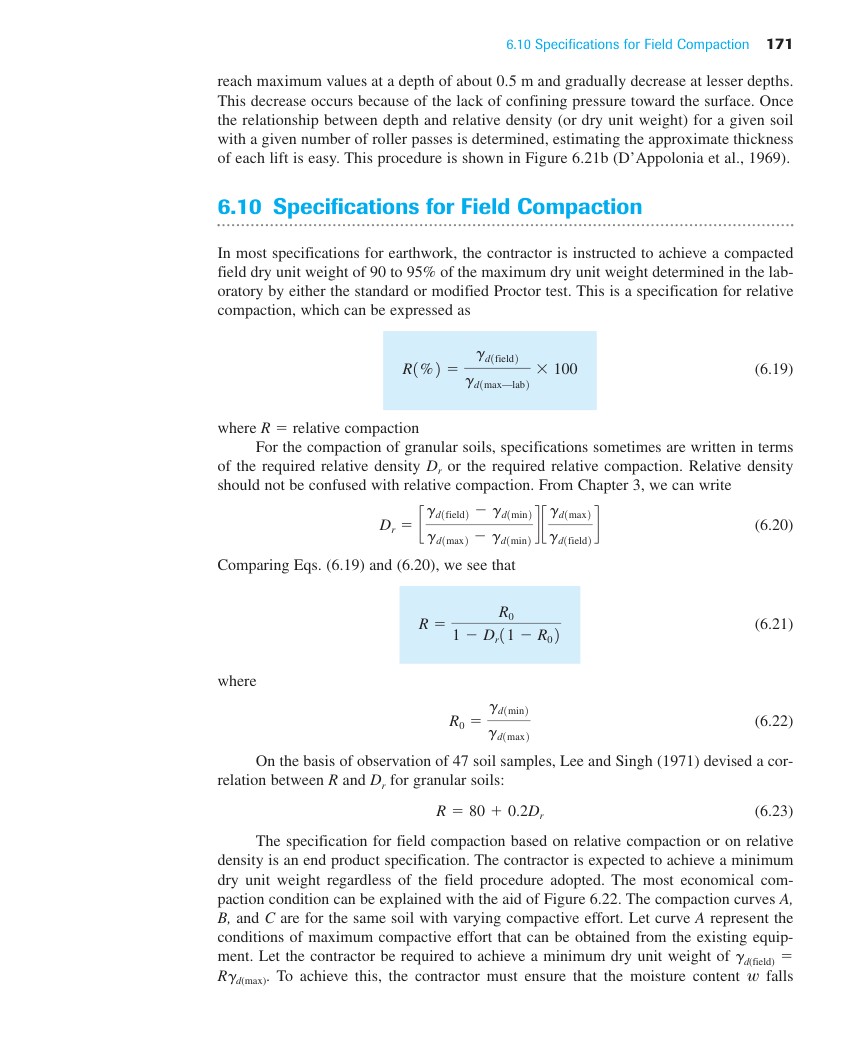

In [7]:
# Display Case B first because Poppler behaved differently from the other parsers on this page.
show_parser_audit_case("B")

This is a very useful result, and it actually caught something in **our audit design** that we should fix before we continue to Cases C, D and E.

### 4.1.1. What Case B tells us already

I checked the actual rendered textbook page 171 against your outputs.

The printed equations really contain normal mathematical notation such as:

* `=` in equations 6.19 to 6.23
* `×` in 6.19
* `−` in 6.20 and 6.21
* `+` in 6.23
* Greek `γ`
* subscripts such as `d(field)`, `d(max)`, `d(min)`

The textbook extraction itself confirms that this section contains equations 6.19 to 6.23 and that these formula components are exactly where the parsers are struggling. 

Now look at what happened.

#### PyMuPDF

It gives:

```text
R1%2 <U+0002> ...
<U+0004> 100
```

So it exposes the problematic embedded mathematical glyphs as control characters.

It also puts most equations near the bottom instead of where they visually occur.

#### pypdf

It gives:

```text
R1%2 /H11005 ...
/H11003 100
```

Same problem, but represented as `/H...` font codes.

#### pdfplumber

It gives:

```text
R % (cid:2) ...
(cid:4)100
```

Again, same problematic characters, represented as CIDs.

Interestingly, pdfplumber preserves the equation positions considerably better than the first two.

#### Poppler

Poppler looks much better at first:

```text
R1%2 ⫽ ... ⫻ 100
```

and:

```text
R ⫽ 80 ⫹ 0.2Dr
```

It also preserves the fraction layout very well.

But there is an important catch.

The source does **not** contain `⫽`, `⫻`, `⫺`, or `⫹`.

It contains ordinary:

```text
=
×
−
+
```

So Poppler has not actually decoded the mathematical font perfectly. It has mapped those problematic glyphs into **visually similar mathematical Unicode characters**.

That explains why our automatic anomaly detector showed:

```text
Poppler controls = 0
```

for Case B.

That did **not** mean:

> Poppler correctly recovered all 13 mathematical symbols.

It meant:

> Poppler converted those problematic font glyphs into visible Unicode symbols instead of control characters.

That is better for readability, but it is not exact character fidelity.

And even Poppler still turns:

```text
γ
```

into:

```text
g
```

and things like the subscripts become:

```text
gd1field2
```

So **none of the four parsers correctly reconstructs the mathematics on Case B**.

This strengthens our earlier conclusion considerably.

The problem is largely associated with the way the textbook's mathematical fonts are encoded, rather than being something uniquely wrong with PyMuPDF.

### 4.1.2. But I caught a fairness problem in our comparison

This is important enough that I don't want us to continue scoring the current outputs.

We gave Poppler:

```bash
-layout
```

but we gave the three Python libraries their default text extraction modes.

That is **not a fully fair comparison for reading order and equation structure**.

For example, PyMuPDF documentation explicitly says that normal:

```python
page.get_text("text")
```

follows the PDF creator's internal text order, which may not correspond to visual reading order.

PyMuPDF provides:

```python
page.get_text("text", sort=True)
```

specifically to reorder text according to its page position. ([pymupdf.readthedocs.io][1])

And the other libraries have equivalents.

Your exact installed pypdf 6.16.2 supports:

```python
page.extract_text(extraction_mode="layout")
```

as a layout-preserving extraction mode. ([pypdf.readthedocs.io][2])

pdfplumber also supports:

```python
page.extract_text(layout=True)
```

which attempts to reproduce the structural layout of the page. ([GitHub][3])

So what we accidentally compared was:

```text
PyMuPDF        plain
pypdf          plain
pdfplumber     plain
Poppler        layout-aware
```

That gives Poppler an unfair advantage specifically on **reading order and equation layout**.

It does not affect our glyph finding, because all four clearly hit the same mathematical-font problem.

But it absolutely affects the decision about which reader is best overall.

### Parser-configuration fairness correction

The initial diagnostic comparison used default/plain text extraction for PyMuPDF, pypdf, and pdfplumber, while Poppler was executed with its `-layout` option.

This comparison remains useful for identifying raw mathematical-character encoding behaviour, but it is not used for the final reading-order or layout ranking because the parser configurations were not equivalent.

A second comparison therefore uses the ordinary layout-aware extraction capability available for each parser. No OCR, semantic formula reconstruction, mathematical correction, or manual symbol replacement is introduced.

## Step 4A: make the comparison configuration-fair

In [8]:
# Define a layout-aware PyMuPDF extraction function.
def extract_with_pymupdf_layout(pdf_file, page_index):
    # Open the source PDF using PyMuPDF.
    document = pymupdf.open(pdf_file)

    # Load the requested zero-based page.
    page = document.load_page(page_index)

    # Extract text while asking PyMuPDF to reconstruct reading order from page coordinates.
    text = page.get_text("text", sort=True)

    # Close the document after extraction is complete.
    document.close()

    # Return the extracted text without semantic cleaning or mathematical correction.
    return text


# Define a layout-aware pypdf extraction function.
def extract_with_pypdf_layout(pdf_file, page_index):
    # Open the source PDF through pypdf.
    reader = PdfReader(str(pdf_file))

    # Select the requested zero-based page.
    page = reader.pages[page_index]

    # Extract text using pypdf's built-in layout extraction mode.
    text = page.extract_text(extraction_mode="layout")

    # Convert a possible None result into an empty string.
    if text is None:
        # Represent missing output consistently without altering real extracted content.
        text = ""

    # Return the extracted text without semantic cleaning or mathematical correction.
    return text


# Define a layout-aware pdfplumber extraction function.
def extract_with_pdfplumber_layout(pdf_file, page_index):
    # Open the source PDF through pdfplumber.
    with pdfplumber.open(str(pdf_file)) as document:
        # Select the requested zero-based page.
        page = document.pages[page_index]

        # Extract text while asking pdfplumber to approximate the source-page layout.
        text = page.extract_text(layout=True)

    # Convert a possible None result into an empty string.
    if text is None:
        # Represent missing output consistently without altering real extracted content.
        text = ""

    # Return the extracted text without semantic cleaning or mathematical correction.
    return text


# Reuse the existing Poppler function because it already uses the layout-preserving -layout mode.
def extract_with_poppler_layout(pdf_file, pdf_page):
    # Call the previously defined Poppler extractor without changing its behaviour.
    return extract_with_poppler(pdf_file, pdf_page)

### 4A.1. Extract the frozen sample again under equivalent layout-aware modes

In [9]:
# Define the names of the layout-aware parser configurations.
layout_parser_names = [
    "pymupdf_layout",
    "pypdf_layout",
    "pdfplumber_layout",
    "poppler_layout",
]


# Create separate storage so the original default-parser results remain untouched.
layout_audit_outputs = {}


# Iterate through every previously frozen audit page.
for audit_case in audit_pages:
    # Read the unique audit-case identifier.
    case_id = audit_case["case_id"]

    # Create storage for the current page.
    layout_audit_outputs[case_id] = {}

    # Extract the current page using layout-aware PyMuPDF.
    layout_audit_outputs[case_id]["pymupdf_layout"] = (
        extract_with_pymupdf_layout(
            pdf_path,
            audit_case["page_index"],
        )
    )

    # Extract the same page using pypdf's layout mode.
    layout_audit_outputs[case_id]["pypdf_layout"] = (
        extract_with_pypdf_layout(
            pdf_path,
            audit_case["page_index"],
        )
    )

    # Extract the same page using pdfplumber's layout mode.
    layout_audit_outputs[case_id]["pdfplumber_layout"] = (
        extract_with_pdfplumber_layout(
            pdf_path,
            audit_case["page_index"],
        )
    )

    # Extract the same page using Poppler's existing layout mode.
    layout_audit_outputs[case_id]["poppler_layout"] = (
        extract_with_poppler_layout(
            pdf_path,
            audit_case["pdf_page"],
        )
    )


# Confirm that all layout-aware extractions completed.
print("Layout-aware extraction completed for all frozen audit cases.\n")


# Print compact structural statistics for every layout-aware output.
for audit_case in audit_pages:
    # Read the current case identifier.
    case_id = audit_case["case_id"]

    # Print the case heading.
    print(
        f"Case {case_id} "
        f"(printed page {audit_case['printed_page']}, "
        f"PDF page {audit_case['pdf_page']}):"
    )

    # Inspect every layout-aware parser result.
    for parser_name in layout_parser_names:
        # Retrieve the untouched extracted text.
        extracted_text = layout_audit_outputs[case_id][parser_name]

        # Count characters in the parser output.
        character_count = len(extracted_text)

        # Count lines in the parser output.
        line_count = len(extracted_text.splitlines())

        # Print the structural statistics.
        print(
            f"  {parser_name:<18} "
            f"characters={character_count:<6} "
            f"lines={line_count}"
        )

    # Separate cases visually.
    print()

Rotated text discovered. Output will be incomplete.
Rotated text discovered. Output will be incomplete.


Layout-aware extraction completed for all frozen audit cases.

Case A (printed page 2, PDF page 26):
  pymupdf_layout     characters=2749   lines=35
  pypdf_layout       characters=2884   lines=57
  pdfplumber_layout  characters=5062   lines=56
  poppler_layout     characters=2281   lines=40

Case B (printed page 171, PDF page 195):
  pymupdf_layout     characters=3071   lines=46
  pypdf_layout       characters=4078   lines=46
  pdfplumber_layout  characters=5766   lines=61
  poppler_layout     characters=3073   lines=51

Case C (printed page 199, PDF page 223):
  pymupdf_layout     characters=2511   lines=59
  pypdf_layout       characters=3101   lines=52
  pdfplumber_layout  characters=5539   lines=61
  poppler_layout     characters=2602   lines=61

Case D (printed page 399, PDF page 423):
  pymupdf_layout     characters=1669   lines=48
  pypdf_layout       characters=2324   lines=46
  pdfplumber_layout  characters=4889   lines=56
  poppler_layout     characters=1984   lines=52

Case

### 4A.2. Run the anomaly test again on the layout versions

In [10]:
# Create storage for anomaly measurements from the layout-aware comparison.
layout_audit_anomalies = {}


# Iterate through every frozen audit page.
for audit_case in audit_pages:
    # Read the current case identifier.
    case_id = audit_case["case_id"]

    # Create storage for parser-specific anomaly measurements.
    layout_audit_anomalies[case_id] = {}

    # Iterate through every layout-aware parser.
    for parser_name in layout_parser_names:
        # Retrieve the untouched layout-aware extraction.
        extracted_text = layout_audit_outputs[case_id][parser_name]

        # Count extraction anomalies using the existing non-destructive diagnostic function.
        layout_audit_anomalies[case_id][parser_name] = (
            count_extraction_anomalies(extracted_text)
        )


# Print the layout-aware anomaly report.
print("Layout-aware extraction-anomaly report:\n")


# Iterate through every frozen audit case.
for audit_case in audit_pages:
    # Read the current case identifier.
    case_id = audit_case["case_id"]

    # Print a heading for the page.
    print(f"Case {case_id}:")

    # Print diagnostics for every layout-aware parser.
    for parser_name in layout_parser_names:
        # Retrieve this parser's measured anomalies.
        anomalies = layout_audit_anomalies[case_id][parser_name]

        # Print the individual anomaly counts.
        print(
            f"  {parser_name:<18} "
            f"replacement={anomalies['replacement_chars']:<3} "
            f"cid={anomalies['cid_placeholders']:<3} "
            f"/H={anomalies['h_placeholders']:<3} "
            f"controls={anomalies['unusual_controls']:<3} "
            f"formfeed={anomalies['form_feeds']}"
        )

    # Separate cases visually.
    print()

Layout-aware extraction-anomaly report:

Case A:
  pymupdf_layout     replacement=0   cid=0   /H=0   controls=0   formfeed=0
  pypdf_layout       replacement=0   cid=0   /H=0   controls=0   formfeed=0
  pdfplumber_layout  replacement=0   cid=0   /H=0   controls=0   formfeed=0
  poppler_layout     replacement=0   cid=0   /H=0   controls=0   formfeed=1

Case B:
  pymupdf_layout     replacement=0   cid=0   /H=0   controls=0   formfeed=0
  pypdf_layout       replacement=0   cid=0   /H=13  controls=0   formfeed=0
  pdfplumber_layout  replacement=0   cid=13  /H=0   controls=0   formfeed=0
  poppler_layout     replacement=0   cid=0   /H=0   controls=0   formfeed=1

Case C:
  pymupdf_layout     replacement=0   cid=0   /H=0   controls=0   formfeed=0
  pypdf_layout       replacement=0   cid=0   /H=16  controls=0   formfeed=0
  pdfplumber_layout  replacement=0   cid=16  /H=0   controls=0   formfeed=0
  poppler_layout     replacement=0   cid=0   /H=0   controls=16  formfeed=1

Case D:
  pymupdf_la

### Then inspect only Case B again first

In [11]:
# Print Case B from every layout-aware parser so reading order and equation structure can be compared fairly.
for parser_name in layout_parser_names:
    # Print a clear parser heading.
    print("=" * 80)
    print(parser_name)
    print("=" * 80)

    # Make invisible controls visible only for notebook inspection.
    print(
        make_controls_visible(
            layout_audit_outputs["B"][parser_name]
        )
    )

    # Add spacing between parser outputs.
    print()

pymupdf_layout
                                               6.10 Specifications for Field Compaction  171

reach maximum values at a depth of about 0.5 m and gradually decrease at lesser depths.
This decrease occurs because of the lack of confining pressure toward the surface. Once
the relationship between depth and relative density (or dry unit weight) for a given soil
with a given number of roller passes is determined, estimating the approximate thickness
of each lift is easy. This procedure is shown in Figure 6.21b (D’Appolonia et al., 1969).

6.10 Specifications for Field Compaction


In most specifications for earthwork, the contractor is instructed to achieve a compacted
field dry unit weight of 90 to 95% of the maximum dry unit weight determined in the lab-
oratory by either the standard or modified Proctor test. This is a specification for relative
compaction, which can be expressed as

                                                      gd1field2                           

In [12]:
# Read the layout-aware Poppler output for Case B.
poppler_case_b = layout_audit_outputs["B"]["poppler_layout"]

# Create a sorted collection of unique non-ASCII symbols found in the extracted output.
non_ascii_characters = sorted(
    {
        character
        for character in poppler_case_b
        if ord(character) > 127
    },
    key=ord,
)

# Print the Unicode identity of every non-ASCII character found by Poppler.
print("Non-ASCII characters in Poppler Case B:\n")

# Inspect every unique non-ASCII character.
for character in non_ascii_characters:
    # Retrieve the official Unicode name when one exists.
    unicode_name = unicodedata.name(character, "UNKNOWN")

    # Print the visible character, code point, and official Unicode name.
    print(
        f"{repr(character):8} "
        f"U+{ord(character):04X} "
        f"{unicode_name}"
    )

Non-ASCII characters in Poppler Case B:

'—'      U+2014 EM DASH
'’'      U+2019 RIGHT SINGLE QUOTATION MARK
'⫹'      U+2AF9 DOUBLE-LINE SLANTED LESS-THAN OR EQUAL TO
'⫺'      U+2AFA DOUBLE-LINE SLANTED GREATER-THAN OR EQUAL TO
'⫻'      U+2AFB TRIPLE SOLIDUS BINARY RELATION
'⫽'      U+2AFD DOUBLE SOLIDUS OPERATOR


In [13]:
# Define a function that runs the existing thesis positioned-text extractor
# on a complete page without depending on the production geometry inventory.
def extract_with_pymupdf_positioned(
    pdf_document,
    page_index,
    pdf_page_number,
):
    # Load the exact source page so its dimensions can be recorded accurately.
    source_page = pdf_document.load_page(
        page_index
    )

    # Create the minimal page record required by the existing thesis extractor.
    # This record is audit-only and does not modify the production geometry.
    audit_page_record = {
        # Store the zero-based page index used by Python PDF libraries.
        "pdf_page_index": page_index,

        # Store the human-visible PDF page number used in the audit records.
        "pdf_page_number": pdf_page_number,

        # Mark the page clearly as a full-page parser-audit record.
        "state": "audit_full_page",

        # Record the exact width required by the extractor's geometry validation.
        "page_width": float(
            source_page.rect.width
        ),

        # Record the exact height required by the extractor's geometry validation.
        "page_height": float(
            source_page.rect.height
        ),

        # Retain the complete vertical page because corpus exclusions
        # must not influence the PDF parser comparison.
        "retained_y_intervals": [
            (
                0.0,
                float(source_page.rect.height),
            )
        ],
    }

    # Run the exact existing thesis positioned-text extractor.
    extracted_page = (
        extract_positioned_lines_from_page(
            pdf_document=pdf_document,
            page_record=audit_page_record,
        )
    )

    # Return the complete positioned page record.
    return extracted_page

In [ ]:
# Open the exact textbook once for the positioned-extractor audit.
positioned_audit_document = pymupdf.open(
    "../data/raw/corpus/"
    "das-sobhan-principles-geotechnical-engineering-8e-si.pdf"
)

# Create storage for the positioned extraction results.
positioned_audit_outputs = {}


# Run the existing thesis extractor on every frozen audit case.
for audit_case in audit_pages:
    # Read the unique audit-case identifier.
    case_id = audit_case["case_id"]

    # Extract the complete page using the existing positioned-text pipeline.
    positioned_audit_outputs[case_id] = (
        extract_with_pymupdf_positioned(
            pdf_document=positioned_audit_document,
            page_index=audit_case["page_index"],
            pdf_page_number=audit_case["pdf_page"],
        )
    )


# Close the textbook after all frozen pages have been processed.
positioned_audit_document.close()


# Confirm successful extraction and report structural statistics.
print(
    "Existing positioned PyMuPDF extraction "
    "completed for all frozen cases.\n"
)

# Inspect each frozen audit case.
for audit_case in audit_pages:
    # Read the current case identifier.
    case_id = audit_case["case_id"]

    # Retrieve the positioned extraction result.
    extracted_page = (
        positioned_audit_outputs[case_id]
    )

    # Print compact structural information for comparison.
    print(
        f"Case {case_id}: "
        f"characters={extracted_page['character_count']}, "
        f"lines={extracted_page['line_count']}"
    )

We get an error output here because the function doesn't exist in this notebook

## Parser audit conclusion

Tophel et al. (2025) report loading PDF documents using appropriate loaders but do not identify the PDF parser or its configuration. The baseline PDF extraction method therefore requires a reconstructed implementation choice.

Four ordinary PDF extraction engines were compared on five fixed, benchmark-independent textbook pages: PyMuPDF, pypdf, pdfplumber, and Poppler. The existing positioned PyMuPDF extraction developed for the thesis was additionally evaluated.

The mathematical test pages showed the same underlying anomaly counts across independent parser families. Cases B, C, D, and E contained respectively 13, 16, 46, and 3 problematic mathematical glyph occurrences. PyMuPDF exposed these as control characters, pypdf as /H-style placeholders, pdfplumber as CID placeholders, and Poppler either as control characters or visually similar but semantically different Unicode mathematical operators. The ordinary prose case contained no such anomalies.

This consistency indicates that the main mathematical extraction limitation originates from the source PDF's embedded mathematical font encoding rather than from PyMuPDF alone.

The existing positioned PyMuPDF extractor was retained for the reconstructed baseline because it preserves unresolved source characters, page geometry, bounding boxes, provenance, and line structure without silently assigning unsupported mathematical meanings. It also integrates with the independently validated corpus-boundary and structural-cleaning pipeline.

The baseline extractor does not attempt semantic equation reconstruction, mathematical OCR, LaTeX conversion, symbolic computation, or formula correction. These remain outside the reconstructed baseline and may be investigated later as a formula-reliability extension.

## Where we are now

We can close this validation gate as:

**PDF parser / extraction decision: PASSED, with documented source-math limitation.**

And importantly, we do **not** need to throw away the extraction work already completed in `01_textbook_layout_exploration.ipynb`.

The pipeline there is still our P0 candidate:

```text
verified Das & Sobhan PDF
        ↓
validated knowledge scope
        ↓
problem + answer leakage exclusion
        ↓
retained page geometry
        ↓
positioned PyMuPDF extraction
        ↓
structural header/page-number removal
        ↓
preserve unresolved mathematical characters
        ↓
formula anomaly audit
        ↓
NEXT: freeze the extracted corpus representation
        ↓
Tophel CharacterTextSplitter 200 / 10
        ↓
embeddings
        ↓
FAISS
```

That means after adding the audit conclusion, **we can return to exactly where we stopped in our `01_textbook_layout_exploration.ipynb` notebook and continue the baseline corpus pipeline**, without introducing formula repair at this stage.